In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df = pd.read_csv("C:/Users/이민정/Desktop/부트캠프/파이널프로젝트/전처리/5_잔액정보_segment_병합.csv")
df

,Segment,기준년월,ID,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,...,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
0,3,201807,0,998,962,22971,0,0,0,1084,...,15988,2440,0,0,0,572,0,17008,0,0
1,4,201807,1,2565,2390,0,0,0,0,4090,...,7045,2677,0,2830,0,2736,0,0,0,0
2,2,201807,2,5312,5113,21531,6795,0,0,5006,...,66549,9118,0,8870,0,4429,0,43351,0,0
3,3,201807,3,730,5025,26284,0,0,0,487,...,30139,884,0,0,0,5097,0,30697,0,0
4,4,201807,4,0,0,0,0,0,0,0,...,28,21,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,4,201812,399995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2399996,3,201812,399996,3351,0,0,0,0,27337,4412,...,67826,12524,0,0,0,0,0,0,0,23031
2399997,2,201812,399997,2524,2960,0,0,0,0,2694,...,8627,3241,0,0,0,3995,0,0,0,0
2399998,4,201812,399998,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [35]:
df.columns[(df == 0).all()]

Index(['카드론잔액_최종경과월', '최종연체개월수_R15M', 'RV잔액이월횟수_R6M', 'RV잔액이월횟수_R3M',
       '연체잔액_일시불_해외_B0M', '연체잔액_RV일시불_해외_B0M', '연체잔액_할부_해외_B0M',
       '연체잔액_CA_해외_B0M'],
      dtype='object')

In [41]:
df = df.drop(['카드론잔액_최종경과월', '최종연체개월수_R15M', 'RV잔액이월횟수_R6M', 'RV잔액이월횟수_R3M',
       '연체잔액_일시불_해외_B0M', '연체잔액_RV일시불_해외_B0M', '연체잔액_할부_해외_B0M',
       '연체잔액_CA_해외_B0M'], axis = 1)

df

,Segment,기준년월,ID,잔액_일시불_B0M,잔액_할부_B0M,잔액_현금서비스_B0M,잔액_리볼빙일시불이월_B0M,잔액_리볼빙CA이월_B0M,잔액_카드론_B0M,월중평잔_일시불_B0M,...,평잔_6M,평잔_일시불_6M,평잔_일시불_해외_6M,평잔_RV일시불_6M,평잔_RV일시불_해외_6M,평잔_할부_6M,평잔_할부_해외_6M,평잔_CA_6M,평잔_CA_해외_6M,평잔_카드론_6M
0,3,201807,0,998,962,22971,0,0,0,1084,...,15988,2440,0,0,0,572,0,17008,0,0
1,4,201807,1,2565,2390,0,0,0,0,4090,...,7045,2677,0,2830,0,2736,0,0,0,0
2,2,201807,2,5312,5113,21531,6795,0,0,5006,...,66549,9118,0,8870,0,4429,0,43351,0,0
3,3,201807,3,730,5025,26284,0,0,0,487,...,30139,884,0,0,0,5097,0,30697,0,0
4,4,201807,4,0,0,0,0,0,0,0,...,28,21,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2399995,4,201812,399995,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2399996,3,201812,399996,3351,0,0,0,0,27337,4412,...,67826,12524,0,0,0,0,0,0,0,23031
2399997,2,201812,399997,2524,2960,0,0,0,0,2694,...,8627,3241,0,0,0,3995,0,0,0,0
2399998,4,201812,399998,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [51]:
df['잔액합계_B0M'] = df['잔액_일시불_B0M'] + df['잔액_할부_B0M'] + df['잔액_현금서비스_B0M'] + df['잔액_리볼빙일시불이월_B0M'] + df['잔액_리볼빙CA이월_B0M'] + df['잔액_카드론_B0M']

In [53]:
a1 = df.groupby('Segment')['잔액합계_B0M'].describe()
a1

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
0,972.0,43775.592593,22392.488480,5800.0,28331.00,39252.5,53498.25,130098.0
1,144.0,53675.222222,30521.209533,7370.0,37667.75,46618.5,57109.75,193489.0
2,127590.0,24036.180390,22606.582550,0.0,8828.00,18424.5,31828.00,261576.0
3,349242.0,15873.855490,20018.628389,0.0,4474.00,9549.5,18208.75,243535.0
4,1922052.0,5828.340324,13730.974323,0.0,0.00,1461.0,5222.00,250530.0


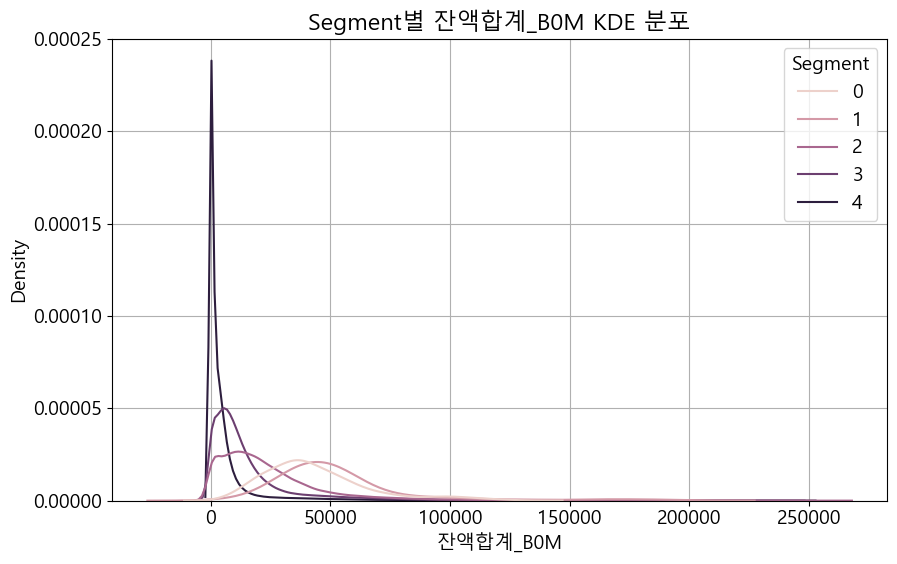

In [55]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='잔액합계_B0M', hue='Segment', common_norm=False)

plt.title('Segment별 잔액합계_B0M KDE 분포')
plt.xlabel('잔액합계_B0M')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [63]:
df['연체합계_B0M'] = df['연체잔액_B0M'] + df['연체잔액_일시불_B0M'] + df['연체잔액_할부_B0M'] + df['연체잔액_현금서비스_B0M']+ df['연체잔액_카드론_B0M']+ df['연체잔액_대환론_B0M']

In [67]:
a2 = df.groupby('Segment')['연체합계_B0M'].describe()
a2

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
0,972.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,144.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,127590.0,15.680045,614.933033,0.0,0.0,0.0,0.0,68708.0
3,349242.0,22.679872,730.526604,0.0,0.0,0.0,0.0,68644.0
4,1922052.0,11.905000,533.149503,0.0,0.0,0.0,0.0,69449.0


In [89]:
df['월중평잔_합계'] = df['월중평잔']+ df['월중평잔_일시불'] + df['월중평잔_RV일시불'] + df['월중평잔_할부'] + df['월중평잔_CA'] + df['월중평잔_카드론']

In [91]:
a3 = df.groupby('Segment')['월중평잔_합계'].describe()
a3

,count,mean,std,min,25%,50%,75%,max
Segment,,,,,,,,
0,972.0,132738.354938,93739.981405,17165.0,70634.75,104839.0,159461.75,481334.0
1,144.0,150022.319444,104190.205393,39070.0,95170.25,120795.0,156908.25,522955.0
2,127590.0,63246.154526,72953.496969,0.0,22039.00,42926.5,74257.25,636050.0
3,349242.0,39352.543013,58156.914972,0.0,11422.25,22149.0,40645.75,686236.0
4,1922052.0,13143.324552,33027.611739,0.0,0.00,3833.0,12056.00,586326.0
